# Power Analysis for LLM Evaluations

**O'Reilly Live Course**: *Statistical Testing for LLM Evaluations*
**Subtitle**: *Design experiments that catch the improvements worth shipping*
**Instructor**: Rudrendu Paul
**Section 3 (20 min): Live Demo 1 of 2: Power analysis (7 min)**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RudrenduPaul/llm-evals-course/blob/main/notebooks/01-power-analysis-llm-evals.ipynb)

---

## What this notebook covers

A team that compares two prompts on 50 examples and finds p > 0.05 has not shown the prompts perform equally. It has shown the experiment lacked the power to detect a difference.

This notebook covers:

1. **The problem**: why 50 examples is almost never enough
2. **Understanding power**: the four-variable relationship behind every test
3. **Required sample sizes**: n = 847 for a 5-point faithfulness improvement on a 0–100 scale
4. **Power analysis by metric type**: binary, ordinal, and judge-based scores need different methods
5. **Rules of thumb**: minimum baselines for meaningful comparisons

Companion book: *Statistical Evaluation Methods for AI Systems* (Paul, O'Reilly, forthcoming), Chapter 5.

**All data is synthetic.** No API keys, no external files.

## Setup

Installs required libraries. Colab-safe, skips packages that are present.

Version conflict in Colab? Run **Runtime → Restart and run all** after the pip install cell.

In [1]:
import sys
!{sys.executable} -m pip install scipy statsmodels matplotlib numpy --quiet

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try brew install
    xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a Python library that isn't in Homebrew,
    use a virtual environment:
    
    python3 -m venv path/to/venv
    source path/to/venv/bin/activate
    python3 -m pip install xyz
    
    If you wish to install a Python application that isn't in Homebrew,
    it may be easiest to use 'pipx install xyz', which will manage a
    virtual environment for you. You can install pipx with
    
    brew install pipx
    
    You may restore the old behavior of pip by passing
    the '--break-system-packages' flag to pip, or by adding
    'break-system-packages = true' to your pip.conf file. The latter
    will permanently disable this error.
    
    If you disable this error, we STRONGLY recommend that you additionally
    pass the '--user' flag to pip, or set 

### Importing libraries

- NumPy: array math, random draws
- Matplotlib: plotting
- SciPy: statistical distributions behind power calculations
- statsmodels: `TTestIndPower`, `NormalIndPower` (analytical power solvers), `proportion_effectsize` (binary-metric conversions)

Analytical solvers return the same answer as a 10,000-run simulation in microseconds, and let you sweep hundreds of parameter combinations for the power curves ahead. Use simulation only to validate an edge case.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
# TTestIndPower: analytical power for two independent groups (unknown equal variance)
# NormalIndPower: same but assumes known variance, used for proportions z-test
from statsmodels.stats.power import TTestIndPower, NormalIndPower
# proportion_effectsize computes Cohen's h: the correct effect size for proportions,
# not Cohen's d. Using Cohen's d on a proportion would be mathematically incorrect.
from statsmodels.stats.proportion import proportion_effectsize
import warnings
warnings.filterwarnings('ignore')

# Global plot style: clean white background, readable fonts
# We set these once rather than repeating rcParams in every plot cell
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.color': '#cccccc',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'lines.linewidth': 2.0,
})

# Seed for reproducibility: every random draw in this notebook uses this seed,
# so students and instructors see the same numbers every run
np.random.seed(42)

print("Setup complete. NumPy:", np.__version__)

Setup complete. NumPy: 2.4.3


---

## Section 1: Why 50 Examples Is Not Enough

An underpowered eval doesn't save you from a bad decision. It disguises the bad decision as "no significant difference."

**The scenario**: two prompt versions for a RAG customer support system, scored on a 0–100 faithfulness scale. Fifty test cases per prompt. Result: p > 0.05, so the team concludes "no significant difference."

That conclusion is wrong. A non-significant p-value does **not** mean the null hypothesis is true. It means there wasn't enough evidence to reject it. Those are different statements.

Think of it like searching a dark room for your keys with a candle. Not finding them doesn't mean they're not there. It means the candle was too dim to see them. An underpowered experiment is a dim candle: the p-value tells you what it saw, nothing more.

### Generating synthetic LLM quality scores

Simulating a 0–100 faithfulness scale with two features common in production LLM eval data:

- **Ceiling effects**: scores cluster near the top, so variance is lower than a uniform distribution suggests. Ceiling effects compress the effective standard deviation and make small improvements harder to detect.
- **A true difference**: Prompt B beats Prompt A by 5 points on average.

Ground truth: Prompt B is better. The question is whether 50 examples can detect it.

In [3]:
def simulate_llm_scores(n, mean, std=10.0, scale_min=0.0, scale_max=100.0, seed=None):
    """
    Simulate LLM faithfulness scores on a 0-100 scale.
    Applies clipping to model ceiling effects, so scores pile up near the top.
    """
    if seed is not None:
        np.random.seed(seed)
    # We draw from a normal distribution as the base, then clip to [scale_min, scale_max].
    # Why normal? It is a reasonable approximation for the underlying quality
    # variation across responses, even though individual scores are bounded.
    # The clipping introduces the ceiling effect we observe in production eval data.
    raw = np.random.normal(loc=mean, scale=std, size=n)
    # np.clip enforces the rubric boundaries. Without clipping, we could get
    # scores of 104 or -3, which violates the rubric definition.
    clipped = np.clip(raw, scale_min, scale_max)
    return clipped


# True population parameters: these represent the ground truth, which we normally do NOT know.
# In a live experiment we are trying to ESTIMATE the difference from data.
# Here we set the truth explicitly so we can check whether our experiment detected it.
TRUE_MEAN_A = 72.0   # Prompt A: baseline faithfulness score (0-100)
TRUE_MEAN_B = 77.0   # Prompt B: better by 5 points
SCORE_STD   = 36.7   # Pooled std, a realistic spread for a noisy 0-100 LLM-judge faithfulness score

# Small experiment: 50 examples per prompt (this is what most teams run)
n_small = 50
scores_A_small = simulate_llm_scores(n_small, TRUE_MEAN_A, SCORE_STD, seed=42)
scores_B_small = simulate_llm_scores(n_small, TRUE_MEAN_B, SCORE_STD, seed=123)

print(f"=== Small experiment (n={n_small} per prompt) ===")
print(f"Prompt A (mean: {scores_A_small.mean():.3f}, std: {scores_A_small.std():.3f})")
print(f"Prompt B (mean: {scores_B_small.mean():.3f}, std: {scores_B_small.std():.3f})")
print(f"Observed difference: {scores_B_small.mean() - scores_A_small.mean():.3f}")
print()

# Two-sample independent t-test.
# Why independent? Each test case goes to one prompt version, not both.
# For paired designs (same test case scored by both prompts), use stats.ttest_rel instead.
# The independent t-test is correct here because the two sample sets are drawn separately.
t_stat, p_value = stats.ttest_ind(scores_B_small, scores_A_small)
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value:     {p_value:.3f}")
print()

if p_value < 0.05:
    print("Result: SIGNIFICANT (p < 0.05)")
else:
    print(f"Result: NOT SIGNIFICANT (p = {p_value:.3f} > 0.05)")
    print()
    print("Common (wrong) interpretation: 'The prompts perform the same.'")
    print("Correct interpretation: 'This experiment did not have enough power")
    print("  to detect the difference reliably. We need more data.'")

=== Small experiment (n=50 per prompt) ===
Prompt A (mean: 60.990, std: 29.386)
Prompt B (mean: 69.206, std: 30.121)
Observed difference: 8.216

t-statistic: 1.367
p-value:     0.175

Result: NOT SIGNIFICANT (p = 0.175 > 0.05)

Common (wrong) interpretation: 'The prompts perform the same.'
Correct interpretation: 'This experiment did not have enough power
  to detect the difference reliably. We need more data.'


**KEY INSIGHT: What a non-significant p means**

- p > 0.05 means: if the null hypothesis were true, a result this extreme would not be unusual by chance
- It does NOT mean the null hypothesis is true, and it does NOT mean there is no difference
- It means the 50-example signal was too faint to clear the threshold
- The p-value is a statement about the data given the null hypothesis, not about the null hypothesis given the data

Correct read: "This experiment was not large enough to detect a 5-point difference reliably."

### Visualizing the score distributions

- **Left panel (n=50)**: distributions overlap heavily, sample means barely distinguishable from noise
- **Right panel (n=847)**: sample means settle near the true values (72, 77), test comes back significant

Same true difference in both panels. Only the sample size changed, and that changed the conclusion.

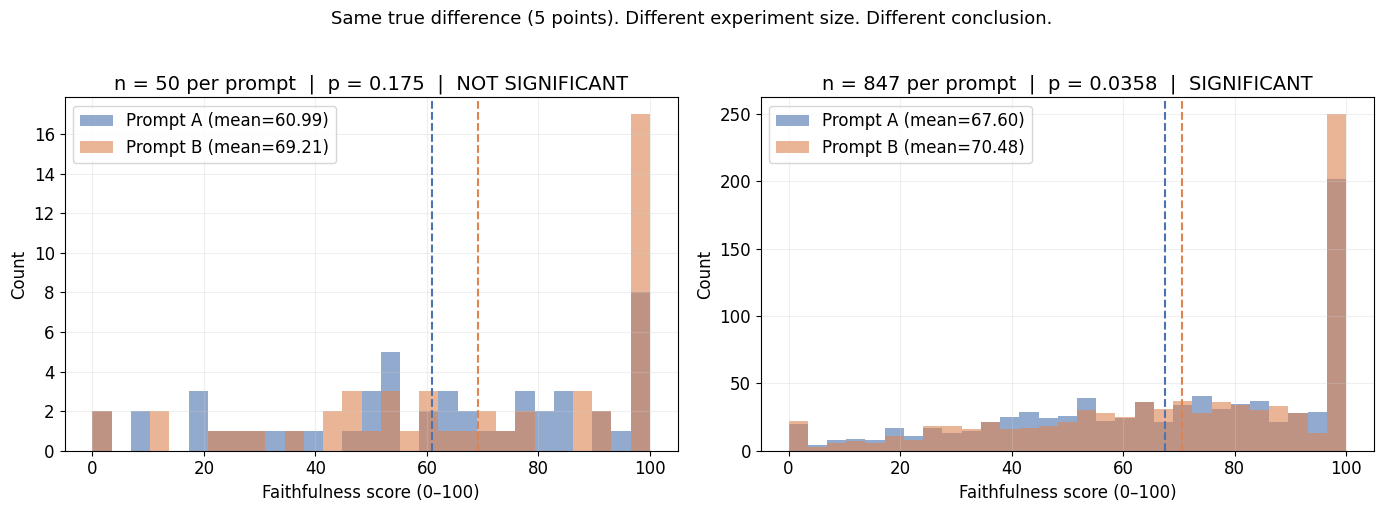


The true difference is 5.00 points in BOTH panels.
With n=50: p = 0.175  -> inconclusive
With n=847: p = 0.0358 -> clear signal


In [4]:
# This visualization shows two panels side by side to make the core argument visual.
# Left panel: n=50 (common practice). Distributions overlap heavily, result not significant.
# Right panel: n=847 (required for this effect size). Distributions separate cleanly.
# The TRUE difference is identical in both panels. Only sample size changes.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: histograms for the small experiment
ax = axes[0]
bins = np.linspace(0, 100, 30)
# Semi-transparent histograms (alpha=0.6) so the overlap region is visible
ax.hist(scores_A_small, bins=bins, alpha=0.6, color='#4C72B0', label=f'Prompt A (mean={scores_A_small.mean():.2f})')
ax.hist(scores_B_small, bins=bins, alpha=0.6, color='#DD8452', label=f'Prompt B (mean={scores_B_small.mean():.2f})')
# Vertical dashed lines mark the sample means, visually showing whether they are distinguishable
ax.axvline(scores_A_small.mean(), color='#4C72B0', linestyle='--', linewidth=1.5)
ax.axvline(scores_B_small.mean(), color='#DD8452', linestyle='--', linewidth=1.5)
ax.set_xlabel('Faithfulness score (0–100)')
ax.set_ylabel('Count')
ax.set_title(f'n = {n_small} per prompt  |  p = {p_value:.3f}  |  NOT SIGNIFICANT')
ax.legend()

# Right panel: what a properly powered experiment looks like
# n=847 comes from the power calculation in Section 3: we preview it here for visual impact
n_large = 847
np.random.seed(42)
scores_A_large = simulate_llm_scores(n_large, TRUE_MEAN_A, SCORE_STD)
np.random.seed(123)
scores_B_large = simulate_llm_scores(n_large, TRUE_MEAN_B, SCORE_STD)
_, p_large = stats.ttest_ind(scores_B_large, scores_A_large)

ax2 = axes[1]
ax2.hist(scores_A_large, bins=bins, alpha=0.6, color='#4C72B0', label=f'Prompt A (mean={scores_A_large.mean():.2f})')
ax2.hist(scores_B_large, bins=bins, alpha=0.6, color='#DD8452', label=f'Prompt B (mean={scores_B_large.mean():.2f})')
ax2.axvline(scores_A_large.mean(), color='#4C72B0', linestyle='--', linewidth=1.5)
ax2.axvline(scores_B_large.mean(), color='#DD8452', linestyle='--', linewidth=1.5)
ax2.set_xlabel('Faithfulness score (0–100)')
ax2.set_ylabel('Count')
ax2.set_title(f'n = {n_large} per prompt  |  p = {p_large:.4f}  |  SIGNIFICANT')
ax2.legend()

# Supertitle reinforces the central lesson: same truth, different sample, different conclusion
fig.suptitle('Same true difference (5 points). Different experiment size. Different conclusion.',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nThe true difference is {TRUE_MEAN_B - TRUE_MEAN_A:.2f} points in BOTH panels.")
print(f"With n={n_small}: p = {p_value:.3f}  -> inconclusive")
print(f"With n={n_large}: p = {p_large:.4f} -> clear signal")

**KEY INSIGHT: The same reality, two different stories**

Only the sample size changed, and the conclusion flipped from "not significant" to "highly significant." Statistical significance isn't a property of the effect alone. It's a joint property of the effect and the experimental design. An underpowered experiment can't produce a reliable answer, no matter how large the true difference is.

---

## Section 2: Understanding Statistical Power

Power quantifies the probability your experiment can back a claim like "Prompt B scored higher." Most practitioners never calculate the power of their eval setup.

---

**Statistical power** is like camera resolution. A 50-example eval is a blurry photo: you might see something, but you can't tell if it's an object or noise. An 847-example eval is high-resolution: you can confidently identify true differences.

Formally: **Power = P(reject H₀ | H₁ is true)**

Standard target: **80% power** (an 80% chance of detecting the effect if it exists). Below 80% power is like a smoke detector that fires only 40% of the time during a fire.

Four variables. Fix any three and the fourth is determined:

| Variable | Symbol | What it controls |
|---|---|---|
| Effect size | δ | Size of the true difference relative to noise |
| Sample size | n | Observations per condition |
| Significance level | α | Type I error rate (usually 0.05) |
| Power | 1 − β | Probability of detecting the effect (β = Type II error rate) |

In practice, α is fixed at 0.05 and power at 0.80 or higher. That leaves effect size and sample size to negotiate: if the budget only allows n=100, you either accept lower power or accept that only larger improvements are detectable. **Effect size comes from domain knowledge** of what improvement matters.

### Calculating the power of the 50-example experiment

Cohen's d, the standardized effect size for a t-test: **d = (mean_B - mean_A) / pooled_std**. Standardizing by the pooled standard deviation makes effect sizes comparable across scales, so a 5-point gain on 0–100 and a 0.5-point gain on 1–5 can share the same d.

**Cohen's d benchmarks for LLM evaluation:**

- **d = 0.20 (small)**: ~7 points on 0–100. Raters would argue about it. Needs ~400 examples.
- **d = 0.50 (medium)**: ~18 points. Most raters agree it's better. Needs ~130 examples.
- **d = 0.80 (large)**: ~29 points, obvious. Needs only ~50 examples, and is rare once a system is tuned.

Our scenario sits at d ≈ 0.14, below "small," the realistic range when comparing two tuned prompts.

In [5]:
# Cohen's d: standardized effect size
# d = (mean_B - mean_A) / pooled_std
# We divide by the pooled std (not just one group's std) to get a scale-free measure.
# This allows comparison across metrics with different units and ranges.
true_difference = TRUE_MEAN_B - TRUE_MEAN_A   # 5 points: this is the RAW effect size
cohens_d = true_difference / SCORE_STD        # this is the STANDARDIZED effect size

print(f"True mean difference: {true_difference:.2f} points")
print(f"Score standard deviation: {SCORE_STD:.2f}")
print(f"Cohen's d (effect size): {cohens_d:.4f}")
print()
print("Cohen's d benchmarks:")
print("  Small effect:  d = 0.20  (subtle; human raters would disagree)")
print("  Medium effect: d = 0.50  (noticeable; most raters agree it's better)")
print("  Large effect:  d = 0.80  (obvious; everyone can see it)")
print(f"\nOur effect (d={cohens_d:.2f}) is classified as: ", end="")
if cohens_d < 0.20:
    print("below small")
elif cohens_d < 0.50:
    print("small")
elif cohens_d < 0.80:
    print("medium")
else:
    print("large")

print()

# We use TTestIndPower rather than NormalIndPower because:
# - Our scenario compares TWO INDEPENDENT groups (Prompt A vs Prompt B)
# - We do NOT know the true population variance: we estimate it from data
# - For PAIRED data (same test case scored by both prompts), we would use TTestPower instead
# - NormalIndPower assumes known variance, which is almost never the case in practice
analysis = TTestIndPower()
power_50 = analysis.solve_power(
    effect_size=cohens_d,
    nobs1=n_small,        # n per group (we have 50 in each condition)
    alpha=0.05,           # Type I error rate (the "false positive" threshold)
    alternative='two-sided'  # we care about improvement in either direction
)

print(f"Power of the n={n_small} experiment: {power_50:.1%}")
print()
print(f"Interpretation: that experiment had only a {power_50:.0%} chance of detecting")
print(f"the 5-point improvement. It was nearly guaranteed to miss it.")
print(f"The probability of a false negative (Type II error): {1 - power_50:.1%}")

True mean difference: 5.00 points
Score standard deviation: 36.70
Cohen's d (effect size): 0.1362

Cohen's d benchmarks:
  Small effect:  d = 0.20  (subtle; human raters would disagree)
  Medium effect: d = 0.50  (noticeable; most raters agree it's better)
  Large effect:  d = 0.80  (obvious; everyone can see it)

Our effect (d=0.14) is classified as: below small

Power of the n=50 experiment: 10.4%

Interpretation: that experiment had only a 10% chance of detecting
the 5-point improvement. It was nearly guaranteed to miss it.
The probability of a false negative (Type II error): 89.6%


**KEY INSIGHT: Power = 10% means the experiment was nearly pointless**

- A 10%-powered experiment has a ~90% chance of missing an improvement that exists
- Run it 10 times: roughly 1 significant result, 9 non-significant
- Teams that read "not significant" as "no improvement" throw away a better prompt 90% of the time

A Type I error (false positive) ships a change that doesn't help. A Type II error (false negative) discards a change that does help, and in LLM product development, Type II errors are usually the costlier mistake.

### Visualizing the power curve

Power rises with sample size, and the rate depends on effect size: large effects need fewer examples, small effects need many more. The curve is flat below n=100, steepens between n=200 and n=800, then flattens again.

Doubling the sample from 50 to 100 barely moves power. Reaching 80% power for a small effect can take an 8–10x increase in n, not 2x.

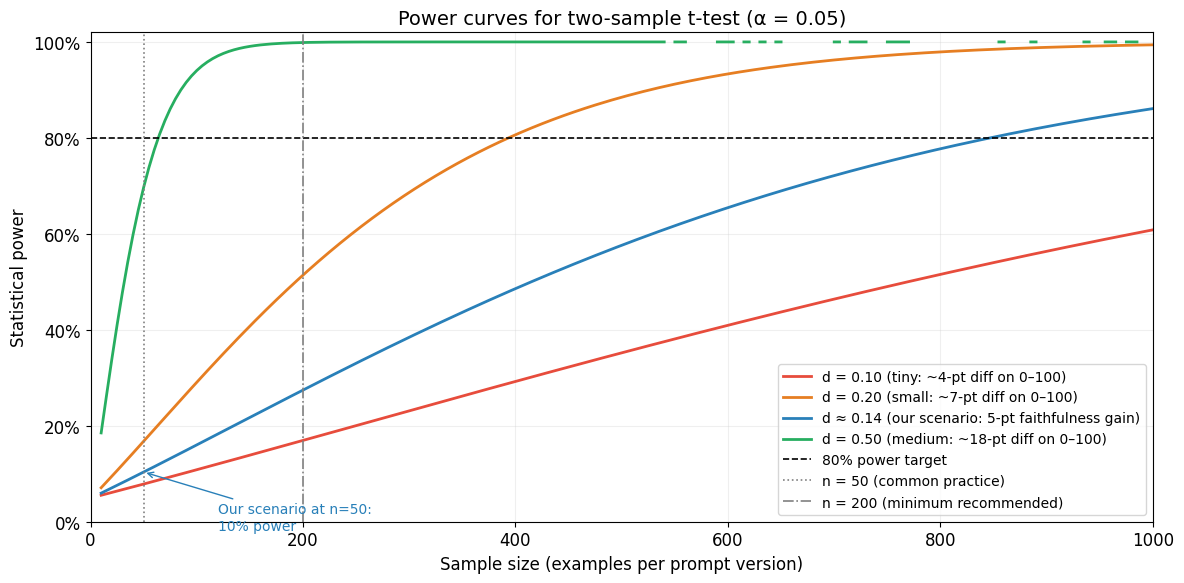


Key insight: at n=50, even a medium effect (d=0.50) achieves only ~70% power.
For the small effects typical in prompt comparisons, you need hundreds of examples.


In [6]:
# We sweep sample sizes from 10 to 1000 in steps of 5 to get a smooth curve.
# Using steps of 1 would be more precise but produces an imperceptibly smoother line.
# Steps of 5 keep computation fast while preserving visual resolution.
sample_sizes = np.arange(10, 1001, 5)

# We show four effect sizes representing the realistic range in LLM evaluation:
# d=0.10 (tiny: essentially undetectable in practice without thousands of examples)
# d=0.20 (small: prompt tuning gains; human raters often disagree)
# d≈0.14 (our scenario: 5-pt faithfulness gain on 0-100 with std≈37)
# d=0.50 (medium: noticeable improvement; most raters agree)
effect_sizes = {
    'd = 0.10 (tiny: ~4-pt diff on 0–100)': 0.10,
    'd = 0.20 (small: ~7-pt diff on 0–100)': 0.20,
    'd ≈ 0.14 (our scenario: 5-pt faithfulness gain)': cohens_d,
    'd = 0.50 (medium: ~18-pt diff on 0–100)': 0.50,
}

# Red to green gradient signals "more detectable" as we move down the legend
colors = ['#e74c3c', '#e67e22', '#2980b9', '#27ae60']

fig, ax = plt.subplots(figsize=(12, 6))

# We re-instantiate TTestIndPower here (rather than reusing the one from above) to
# make this cell self-contained and runnable even if cells above were skipped
analysis = TTestIndPower()

for (label, d), color in zip(effect_sizes.items(), colors):
    # For each effect size, compute the power at every sample size.
    # solve_power with nobs1 specified (and power=None) returns the power value.
    powers = [analysis.solve_power(effect_size=d, nobs1=n, alpha=0.05, alternative='two-sided')
              for n in sample_sizes]
    ax.plot(sample_sizes, powers, label=label, color=color)

# The 80% reference line is the standard target. Below this line, experiments
# are considered underpowered for professional research purposes
ax.axhline(0.80, color='black', linestyle='--', linewidth=1.2, label='80% power target')

# n=50 reference: this is what most teams run. Notice it is far below 80% for
# all but the largest effect sizes.
ax.axvline(50, color='gray', linestyle=':', linewidth=1.2, label='n = 50 (common practice)')

# n=200 is the practical minimum we recommend: still insufficient for tiny effects,
# but adequate for the medium range that most comparisons fall into
ax.axvline(200, color='gray', linestyle='-.', linewidth=1.2, label='n = 200 (minimum recommended)')

ax.set_xlabel('Sample size (examples per prompt version)')
ax.set_ylabel('Statistical power')
ax.set_title('Power curves for two-sample t-test (α = 0.05)')
ax.set_ylim(0, 1.02)
ax.set_xlim(0, 1000)
# Format y-axis as percentages to make the 80% target immediately readable
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend(loc='lower right', fontsize=10)

# Arrow annotation marking where our scenario falls at n=50
ax.annotate(
    f'Our scenario at n=50:\n{power_50:.0%} power',
    xy=(50, power_50),
    xytext=(120, power_50 - 0.12),
    arrowprops=dict(arrowstyle='->', color='#2980b9'),
    color='#2980b9',
    fontsize=10
)

plt.tight_layout()
plt.show()

print("\nKey insight: at n=50, even a medium effect (d=0.50) achieves only ~70% power.")
print("For the small effects typical in prompt comparisons, you need hundreds of examples.")

**KEY INSIGHT: The curve is flat where teams operate**

At n=50:
- d=0.10 (tiny): power below 10%
- d=0.20 (small): power ~17%
- d≈0.14 (our scenario): power ~10%, nine misses out of ten
- d=0.50 (medium): power only ~70%

Most teams run evals in the n=20 to n=100 range, right where the curve is flat. Only large, obvious improvements are detectable there.

---

## Section 3: How Many Examples Do You Need?

Flip the question: given 80% power and a minimum improvement that matters, how many examples do you need?

**Book's worked example**: detect a 5-point faithfulness improvement on a 0–100 scale (std ≈ 37, d ≈ 0.14), at 80% power, α = 0.05.

**Required n = 847, not 50.**

**Cost check**: at $0.10 per API call, 847 examples costs $85, against the cost of shipping a prompt regression at scale.

The minimum meaningful improvement is a product decision, not a statistical one. If faithfulness goes from 65 to 66, most teams wouldn't ship it. From 65 to 70, most would. Statistics tells you how many examples you need once you decide what counts as meaningful.

### Computing required sample sizes for common LLM evaluation scenarios

As d halves, required n roughly quadruples, an inverse-square relationship. Detecting a 3-point improvement instead of a 5-point one needs nearly 3x the data, not a bit more.

In [7]:
# Re-instantiate here so this section is runnable independently
analysis = TTestIndPower()

def required_n(effect_size_d, alpha=0.05, power=0.80):
    """Return required n per group for a two-sample t-test."""
    # solve_power with power specified (and nobs1=None) returns the required sample size.
    # This is the inverse of what we did in Section 2, where we specified nobs1 and solved for power.
    # The same analytical formula, solved for a different variable.
    n = analysis.solve_power(
        effect_size=effect_size_d,
        alpha=alpha,
        power=power,
        alternative='two-sided'
    )
    # np.ceil because sample sizes must be integers, and we always round UP:
    # rounding down would give us slightly less than the target power
    return int(np.ceil(n))


# --- Scenario 1: Coherence on a 1–5 rubric, std ≈ 0.90 ---
# This is the scenario we have been working with throughout Sections 1 and 2
std_rubric_15 = 0.90

# --- Scenario 2: Faithfulness on a 0–100 scale, std ≈ 37 (noisy LLM judge) ---
# Faithfulness measures how well a RAG response is grounded in the retrieved context.
# Scores on 0-100 scales tend to have larger absolute variance even if relative
# variation is similar, hence the larger std_dev value.
std_faithfulness = 36.7

print("=" * 70)
print("COHERENCE on a 1–5 rubric  (std ≈ 0.90)")
print("=" * 70)
for diff in [0.10, 0.20, 0.30, 0.50, 1.00]:
    d = diff / std_rubric_15
    n = required_n(d)
    print(f"  Detect {diff:.2f}-pt improvement  (d={d:.2f})  ->  n = {n:>5} per prompt")

print()
print("=" * 70)
print("FAITHFULNESS on a 0–100 scale  (std ≈ 37)")
print("=" * 70)
for diff in [3, 5, 10, 15, 20]:
    d = diff / std_faithfulness
    n = required_n(d)
    marker = "  <-- book example" if diff == 5 else ""
    print(f"  Detect {diff:>2}-pt improvement  (d={d:.2f})  ->  n = {n:>5} per prompt{marker}")

print()
print("=" * 70)
print("ANSWER TO BOOK EXAMPLE")
print("=" * 70)
d_book = 5.0 / 36.7
n_book = required_n(d_book)
print(f"To detect a 5-point faithfulness improvement with 80% power at p < 0.05:")
print(f"  Cohen's d = {d_book:.4f}")
print(f"  Required n = {n_book} per RAG configuration (not 50)")

COHERENCE on a 1–5 rubric  (std ≈ 0.90)
  Detect 0.10-pt improvement  (d=0.11)  ->  n =  1273 per prompt
  Detect 0.20-pt improvement  (d=0.22)  ->  n =   319 per prompt
  Detect 0.30-pt improvement  (d=0.33)  ->  n =   143 per prompt
  Detect 0.50-pt improvement  (d=0.56)  ->  n =    52 per prompt
  Detect 1.00-pt improvement  (d=1.11)  ->  n =    14 per prompt

FAITHFULNESS on a 0–100 scale  (std ≈ 37)
  Detect  3-pt improvement  (d=0.08)  ->  n =  2351 per prompt
  Detect  5-pt improvement  (d=0.14)  ->  n =   847 per prompt  <-- book example
  Detect 10-pt improvement  (d=0.27)  ->  n =   213 per prompt
  Detect 15-pt improvement  (d=0.41)  ->  n =    95 per prompt
  Detect 20-pt improvement  (d=0.54)  ->  n =    54 per prompt

ANSWER TO BOOK EXAMPLE
To detect a 5-point faithfulness improvement with 80% power at p < 0.05:
  Cohen's d = 0.1362
  Required n = 847 per RAG configuration (not 50)


**KEY INSIGHT: n = 847 is the number that should change your eval policy**

- 847 per RAG configuration (1,694 total) vs the 50 most teams run: 17x larger
- An underpowered "not significant" result may have discarded a better retrieval strategy
- Cost: 1,694 examples at $0.10/call = $169.40

The financial barrier to properly powered evals is lower than the organizational barrier. The problem is habit, not cost.

### Sample size table for common LLM evaluation scenarios

A reference to screenshot and post in your team's Slack. The point isn't to memorize numbers, it's to internalize the order of magnitude.

In [8]:
scenarios = [
    # (scenario_label, improvement_description, effect_size_d)
    # Large gains (d > 0.80): these are detectable with modest sample sizes
    # but rarely occur in practice when comparing two tuned prompts
    ("Prompt A vs B: large coherence gain",      "1.0 pt on 1–5",   1.00/0.90),
    ("Prompt A vs B: medium coherence gain",     "0.5 pt on 1–5",   0.50/0.90),
    # Small gains (d ≈ 0.33): the realistic range for prompt comparisons
    # This is where most teams operate, and where underpowering hurts most
    ("Prompt A vs B: small coherence gain",      "0.3 pt on 1–5",   0.30/0.90),
    ("Prompt A vs B: tiny coherence gain",       "0.2 pt on 1–5",   0.20/0.90),
    # Faithfulness scenarios for RAG evaluation
    # Large faithfulness gains (d > 1.0) can occur when switching retrieval strategies entirely
    ("RAG config: large faithfulness gain",      "20 pt on 0–100",  20.0/36.7),
    ("RAG config: medium faithfulness gain",     "10 pt on 0–100",  10.0/36.7),
    # 5-point improvement on 0-100: the book's worked example (n=847)
    ("RAG config: small faithfulness gain",      " 5 pt on 0–100",  5.0/36.7),
    # 3-point improvement: barely above measurement noise, requires massive n
    ("RAG config: tiny faithfulness gain",       " 3 pt on 0–100",  3.0/36.7),
    # Answer accuracy scenarios for QA and factual retrieval systems
    ("Model A vs B: large answer accuracy gain",  "10 pt on 0–100", 10.0/12.0),
    ("Model A vs B: small answer accuracy gain",  " 5 pt on 0–100",  5.0/12.0),
]

# Two columns for n: 80% power (the standard minimum) and 90% power
# (used when the cost of a false negative is especially high, e.g., safety evaluations)
print(f"{'Scenario':<45} {'Improvement':<20} {'Cohen d':>8} {'n (80%pwr)':>12} {'n (90%pwr)':>12}")
print("-" * 100)

for label, improvement, d in scenarios:
    n80 = required_n(d, power=0.80)
    n90 = required_n(d, power=0.90)
    print(f"{label:<45} {improvement:<20} {d:>8.3f} {n80:>12,} {n90:>12,}")

print()
# Critical reminder: these are PER CONDITION, not total
print("Note: n shown is per condition. Total test cases = 2 × n.")
print("Alpha = 0.05 throughout. Two-sided test.")

Scenario                                      Improvement           Cohen d   n (80%pwr)   n (90%pwr)
----------------------------------------------------------------------------------------------------
Prompt A vs B: large coherence gain           1.0 pt on 1–5           1.111           14           19
Prompt A vs B: medium coherence gain          0.5 pt on 1–5           0.556           52           70
Prompt A vs B: small coherence gain           0.3 pt on 1–5           0.333          143          191
Prompt A vs B: tiny coherence gain            0.2 pt on 1–5           0.222          319          427
RAG config: large faithfulness gain           20 pt on 0–100          0.545           54           72
RAG config: medium faithfulness gain          10 pt on 0–100          0.272          213          285
RAG config: small faithfulness gain            5 pt on 0–100          0.136          847        1,134
RAG config: tiny faithfulness gain             3 pt on 0–100          0.082        

### Visualizing required sample size vs effect size

The curve is hyperbolic: as effect size approaches zero, required n approaches infinity. You must set a minimum meaningful improvement before designing an experiment. Evaluation without one isn't experimentation, it's fishing.

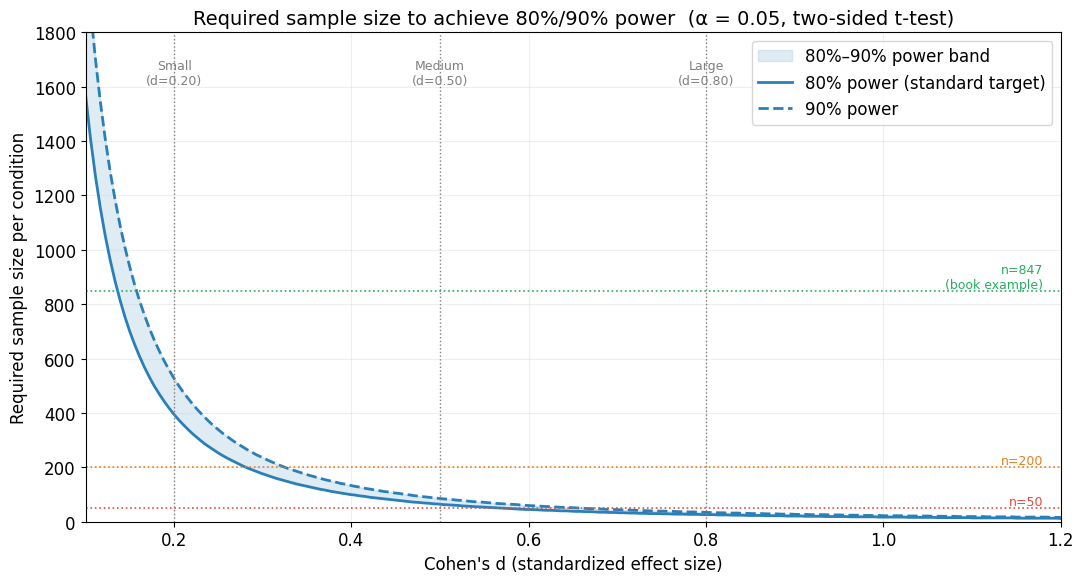

In [9]:
# We sweep 200 points across the effect size range 0.10 to 1.20.
# Lower limit: d=0.10 because smaller effects require impractically large n (>1600 per group)
# Upper limit: d=1.20 because most LLM improvement scenarios fall below d=1.0
effect_sizes_range = np.linspace(0.10, 1.20, 200)

# Compute required n at both power levels for every effect size in the range
n_required_80 = [required_n(d, power=0.80) for d in effect_sizes_range]
n_required_90 = [required_n(d, power=0.90) for d in effect_sizes_range]

fig, ax = plt.subplots(figsize=(11, 6))

# Shaded band between 80% and 90% shows the range of "acceptable" sample sizes
# for a given effect size, useful for communicating flexibility in the budget
ax.fill_between(effect_sizes_range, n_required_80, n_required_90,
                alpha=0.15, color='#2980b9', label='80%–90% power band')
ax.plot(effect_sizes_range, n_required_80, color='#2980b9', label='80% power (standard target)')
ax.plot(effect_sizes_range, n_required_90, color='#2980b9', linestyle='--', label='90% power')

# Vertical lines at Cohen's canonical benchmarks give students reference points
# to read off "how many examples for a small/medium/large effect"
for d_ref, label, ypos in [(0.20, 'Small\n(d=0.20)', 1600), (0.50, 'Medium\n(d=0.50)', 1600), (0.80, 'Large\n(d=0.80)', 1600)]:
    ax.axvline(d_ref, color='gray', linestyle=':', linewidth=1)
    ax.text(d_ref, ypos, label, ha='center', va='bottom', fontsize=9, color='gray')

# Horizontal lines at key n values show what common sample size choices are worth
# n=50 (red): clearly insufficient for all but large effects
# n=200 (orange): minimum viable for medium effects
# n=847 (green): required for the book's worked example (d≈0.14)
ax.axhline(50,  color='#e74c3c', linestyle=':', linewidth=1.2)
ax.text(1.18, 50,  'n=50',  ha='right', va='bottom', color='#e74c3c', fontsize=9)
ax.axhline(200, color='#e67e22', linestyle=':', linewidth=1.2)
ax.text(1.18, 200, 'n=200', ha='right', va='bottom', color='#e67e22', fontsize=9)
ax.axhline(847, color='#27ae60', linestyle=':', linewidth=1.2)
ax.text(1.18, 847, 'n=847\n(book example)', ha='right', va='bottom', color='#27ae60', fontsize=9)

ax.set_xlabel("Cohen's d (standardized effect size)")
ax.set_ylabel('Required sample size per condition')
ax.set_title('Required sample size to achieve 80%/90% power  (α = 0.05, two-sided t-test)')
ax.set_ylim(0, 1800)
ax.set_xlim(0.10, 1.20)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

**KEY INSIGHT: Reading the chart as a decision tool**

Find your target effect size on the x-axis, read up to the 80% power curve for the required n:

- d≈0.14 (book example): n=847
- d=0.50 (medium): n=130 per condition, 260 total
- d=0.20 (small): n=393 per condition, 786 total

n=50 is insufficient below d=0.70. n=200 only clears 80% power above d=0.40. Most practitioners work in d=0.20 to d=0.50, so n=130 to n=393 per condition is the realistic target.

---

## Section 4: Power Analysis for LLM Metrics

The t-test covers continuous metrics: model scores, rubric averages, embedding similarity. Using the wrong test on other types produces a systematic undercount in sample size, leaving you underpowered without knowing it. Three more types matter in practice:

1. **Binary** (pass/fail, safe/unsafe): factual accuracy, tool call success, safety classification. Use a proportions z-test.
2. **Ordinal** (1–5 rubric, Likert): human evaluation, rubric scoring. Use the Mann-Whitney U approximation.
3. **Judge-based** (LLM-as-judge scores): GPT-4 or Claude scoring as an automated evaluator, adding its own noise on top of the quality signal. Use a t-test with effective standard deviation.

Most production pipelines mix all three: factual accuracy binary, coherence ordinal, helpfulness judge-based. Applying the t-test to all three gets two of them wrong.

### Binary metrics: pass/fail rates

Common cases: factual accuracy (correct/incorrect), safety classification (safe/unsafe), tool call success (succeeded/failed), refusal rate (refused/not refused).

Effect size: Cohen's h = 2 × arcsin(√p₁) − 2 × arcsin(√p₂). Proportions near 0 or 1 follow a binomial distribution, not a normal one, so the arcsine transformation stabilizes variance whether your baseline is 10% or 90%.

In [10]:
from statsmodels.stats.proportion import proportion_effectsize

def required_n_binary(p_baseline, p_improved, alpha=0.05, power=0.80):
    """
    Required sample size per group to detect a change in a binary (pass/fail) metric.
    Uses Cohen's h as the effect size measure for proportions.
    """
    # proportion_effectsize computes Cohen's h = 2*arcsin(sqrt(p1)) - 2*arcsin(sqrt(p2))
    # The arcsine transformation stabilizes variance across the probability scale.
    # Without this transformation, the same raw difference (e.g., 5 pp) would imply
    # different effect sizes at p=0.50 vs p=0.95. Cohen's h corrects for that.
    h = proportion_effectsize(p_improved, p_baseline)

    # We use NormalIndPower (z-test for proportions) rather than TTestIndPower here
    # because proportions follow a binomial distribution, and the normal approximation
    # is appropriate for the z-test for proportions.
    # TTestIndPower would be wrong: it assumes continuous data with unknown variance.
    analysis = NormalIndPower()
    n = analysis.solve_power(
        effect_size=abs(h),  # abs() because we care about magnitude, not direction
        alpha=alpha,
        power=power,
        alternative='two-sided'
    )
    return int(np.ceil(n)), abs(h)


print("BINARY METRICS: required sample size per condition")
print("(alpha=0.05, two-sided, 80% power)")
print()
print(f"{'Scenario':<45} {'Baseline':>10} {'Improved':>10} {'Cohen h':>9} {'n required':>12}")
print("-" * 90)

binary_scenarios = [
    # Factual accuracy scenarios: middle range proportions have the most sensitivity
    ("Factual accuracy: 70% → 75%",        0.70, 0.75),
    ("Factual accuracy: 70% → 80%",        0.70, 0.80),
    ("Factual accuracy: 70% → 85%",        0.70, 0.85),
    # Tool call success: slightly higher baseline
    ("Tool call success: 80% → 85%",       0.80, 0.85),
    ("Tool call success: 80% → 90%",       0.80, 0.90),
    # Safety filter: high baseline means detecting small improvements requires huge n
    ("Safety filter pass-rate: 95% → 98%", 0.95, 0.98),
    ("Safety filter pass-rate: 90% → 95%", 0.90, 0.95),
]

for label, p_base, p_imp in binary_scenarios:
    n, h = required_n_binary(p_base, p_imp)
    print(f"{label:<45} {p_base:>10.0%} {p_imp:>10.0%} {h:>9.3f} {n:>12,}")

print()
print("Key insight: detecting a 5-percentage-point improvement at 70% baseline")
print("requires many more examples than most teams allocate.")

BINARY METRICS: required sample size per condition
(alpha=0.05, two-sided, 80% power)

Scenario                                        Baseline   Improved   Cohen h   n required
------------------------------------------------------------------------------------------
Factual accuracy: 70% → 75%                          70%        75%     0.112        1,250
Factual accuracy: 70% → 80%                          70%        80%     0.232          292
Factual accuracy: 70% → 85%                          70%        85%     0.364          119
Tool call success: 80% → 85%                         80%        85%     0.132          903
Tool call success: 80% → 90%                         80%        90%     0.284          195
Safety filter pass-rate: 95% → 98%                   95%        98%     0.167          562
Safety filter pass-rate: 90% → 95%                   90%        95%     0.192          424

Key insight: detecting a 5-percentage-point improvement at 70% baseline
requires many more ex

**KEY INSIGHT: Safety metrics need the most data, not the least**

The high-baseline trap: detecting a 3-point gain (95% → 98%) needs dramatically more examples than a 10-point gain in factual accuracy (70% → 80%), because proportions near 1 have almost no variance.

Teams running safety checks need the largest sample sizes but often run the smallest evals, since safety failures are rare by design. "We tested on 100 prompts and it looked fine" is not a credible safety claim.

### Ordinal metrics: rubric scores and Likert ratings

Common cases: 1–5 human rubrics, LLM judge integer scores, Likert items, comparative "better/same/worse" ratings.

On a bounded scale, a t-test is misspecified: the distribution can't be normal, and equal-variance breaks near the boundaries. Mann-Whitney U fits better: it tests whether one group's values run higher, a rank-based comparison with no normality assumption.

Power approximation uses AUC (probability a random group B observation exceeds group A). The `0.864` divisor in the code below is a conservative efficiency penalty for Mann-Whitney on bounded ordinal scales.

In [11]:
def auc_to_cohens_d(auc):
    """
    Convert AUC (common language effect size) to Cohen's d approximation.
    Reference: Ruscio (2008). A probability-based measure of effect size.
    d ≈ (2 * norminv(AUC)) / sqrt(2) is a common approximation.
    """
    # Clip to avoid numerical issues at AUC=0 or AUC=1 (infinite z-scores)
    auc = np.clip(auc, 0.501, 0.999)
    # stats.norm.ppf is the inverse CDF (quantile function) of the standard normal.
    # ppf(0.84) ≈ 1.0, which is why d=1.0 corresponds approximately to AUC=0.84.
    z = stats.norm.ppf(auc)
    # The sqrt(2) factor converts from the z-score of the AUC to Cohen's d.
    # Derivation: under normality, AUC = Phi(d / sqrt(2)), so d = sqrt(2) * Phi^-1(AUC)
    return z * np.sqrt(2)


def estimate_auc_from_scores(mean_a, mean_b, std_pooled):
    """
    Estimate the AUC (P(B > A)) from distribution parameters,
    assuming both groups are approximately normal.
    AUC = Phi(delta / (std_a^2 + std_b^2)^0.5) where delta = mean_b - mean_a.
    Assuming equal variances: AUC = Phi(delta / (std * sqrt(2)))
    """
    delta = mean_b - mean_a
    # We use equal-variance assumption (both groups have std_pooled)
    # If your data has different variances per group, you would need to
    # use the full formula with separate std estimates for each group
    auc = stats.norm.cdf(delta / (std_pooled * np.sqrt(2)))
    return auc


def required_n_ordinal(mean_a, mean_b, std_pooled, alpha=0.05, power=0.80):
    """
    Required n per group for an ordinal metric using Mann-Whitney U
    power approximation via the AUC-to-d conversion.
    The Mann-Whitney test requires ~1/0.864 more samples than the t-test
    under normality (efficiency = 3/pi ≈ 0.955 for large n; we use 0.864
    as a conservative multiplier for bounded ordinal scales).
    """
    auc = estimate_auc_from_scores(mean_a, mean_b, std_pooled)
    d_approx = auc_to_cohens_d(auc)

    # Step 1: compute the t-test equivalent n
    analysis = TTestIndPower()
    n_ttest = analysis.solve_power(
        effect_size=d_approx, alpha=alpha, power=power, alternative='two-sided'
    )
    # Step 2: apply efficiency penalty for Mann-Whitney on bounded ordinal scales.
    # We divide by 0.864 (multiply by ~1.16) to inflate n appropriately.
    # This reflects the fact that rank-based tests lose some power relative to the
    # optimal t-test when the normality assumption is only weakly violated.
    n_mw = n_ttest / 0.864
    return int(np.ceil(n_mw)), auc, d_approx


print("ORDINAL METRICS (1–5 rubric): required sample size per condition")
print("Using Mann-Whitney U power approximation  (alpha=0.05, 80% power)")
print()
print(f"{'Scenario':<40} {'Mean A':>7} {'Mean B':>7} {'AUC':>7} {'d_approx':>10} {'n (MW)':>10}")
print("-" * 85)

ordinal_scenarios = [
    ("Coherence: 3.5 → 4.0",  3.5, 4.0, 0.90),   # large improvement, easier to detect
    ("Coherence: 3.5 → 3.8",  3.5, 3.8, 0.90),   # our running example
    ("Coherence: 3.5 → 3.6",  3.5, 3.6, 0.90),   # tiny improvement, many examples needed
    ("Helpfulness: 3.0 → 3.5",3.0, 3.5, 1.00),   # std=1.0 because more variance away from ceiling
    ("Helpfulness: 3.0 → 3.3",3.0, 3.3, 1.00),
    ("Relevance: 4.0 → 4.3",  4.0, 4.3, 0.75),   # ceiling effect: std=0.75 because scores pile up near 5
]

for label, ma, mb, std_p in ordinal_scenarios:
    n, auc, d_approx = required_n_ordinal(ma, mb, std_p)
    print(f"{label:<40} {ma:>7.1f} {mb:>7.1f} {auc:>7.3f} {d_approx:>10.3f} {n:>10,}")

print()
# The relevance row demonstrates how ceiling effects raise required n
print("Note: ceiling effects (relevance near 4.0) compress variance, making detection harder.")

ORDINAL METRICS (1–5 rubric): required sample size per condition
Using Mann-Whitney U power approximation  (alpha=0.05, 80% power)

Scenario                                  Mean A  Mean B     AUC   d_approx     n (MW)
-------------------------------------------------------------------------------------
Coherence: 3.5 → 4.0                         3.5     4.0   0.653      0.556         60
Coherence: 3.5 → 3.8                         3.5     3.8   0.593      0.333        165
Coherence: 3.5 → 3.6                         3.5     3.6   0.531      0.111      1,473
Helpfulness: 3.0 → 3.5                       3.0     3.5   0.638      0.500         74
Helpfulness: 3.0 → 3.3                       3.0     3.3   0.584      0.300        203
Relevance: 4.0 → 4.3                         4.0     4.3   0.611      0.400        115

Note: ceiling effects (relevance near 4.0) compress variance, making detection harder.


**KEY INSIGHT: Ceiling effects require more data, not less**

The Relevance row has the same 0.3-point improvement as Coherence, but a larger required n, because std is compressed near the ceiling (0.75 vs 0.90). Less variance means worse signal-to-noise, not easier detection, so it demands more data.

### Judge-based metrics: accounting for judge noise

Common cases: GPT-4/Claude scoring helpfulness or groundedness, automated preference judgments, LLM rubric scoring, RAGAS-style frameworks.

Observed variance has two parts: **signal variance** (quality variation you want to measure) and **judge noise** (the judge scores the same response differently on repeat calls). Ignore judge noise and you inflate the apparent effect size, understate required n, and end up with an experiment that can't detect what you're looking for.

**σ_eff = √(σ_signal² + σ_judge²)**

To estimate judge noise: score the same 20–50 responses twice and take the std of the differences. A well-calibrated judge runs σ_judge ≈ 3–5; a poorly calibrated one, 10–15+.

In [12]:
def required_n_judge_based(mean_diff, sigma_signal, sigma_judge, alpha=0.05, power=0.80):
    """
    Required n per group for an LLM-judge metric, accounting for judge noise.

    Parameters
    ----------
    mean_diff   : expected improvement in score units
    sigma_signal: true standard deviation of response quality
    sigma_judge : standard deviation of judge scoring noise
                  (estimated by scoring the same responses twice and computing std of differences)
    """
    # Combine signal and judge noise in quadrature (square root of sum of squares).
    # This is correct when the two variance sources are independent: a reasonable
    # assumption because judge inconsistency and response quality variation are
    # driven by different mechanisms.
    sigma_eff = np.sqrt(sigma_signal**2 + sigma_judge**2)

    # d_naive: what you would calculate if you naively used only sigma_signal.
    # This OVERESTIMATES the effect size and UNDERESTIMATES required n.
    # Teams that use d_naive will build experiments that are systematically underpowered.
    d_naive = mean_diff / sigma_signal

    # d_eff: the correct effect size, accounting for the full observed variance.
    # This is smaller than d_naive whenever sigma_judge > 0.
    d_eff   = mean_diff / sigma_eff

    analysis = TTestIndPower()
    n_naive = int(np.ceil(analysis.solve_power(effect_size=d_naive, alpha=alpha, power=power, alternative='two-sided')))
    n_eff   = int(np.ceil(analysis.solve_power(effect_size=d_eff,   alpha=alpha, power=power, alternative='two-sided')))

    return {
        'sigma_signal': sigma_signal,
        'sigma_judge':  sigma_judge,
        'sigma_eff':    sigma_eff,
        'd_naive':      d_naive,   # the wrong number teams often use
        'd_eff':        d_eff,     # the correct number
        'n_naive':      n_naive,   # how many examples a naive calculation says you need
        'n_effective':  n_eff,     # how many examples you need
        'undercount':   n_eff - n_naive,  # the gap the naive calc misses
    }


print("JUDGE-BASED METRICS: impact of judge noise on required sample size")
print("Scenario: detecting a 5-point coherence improvement on a 0–100 scale")
print()

mean_improvement = 5.0
sigma_signal = 12.0  # true variation in response quality across prompts/test cases

# We sweep from 0 (perfect judge, no noise) to 15 (highly inconsistent judge)
# to show how the undercount grows as judge noise increases
judge_noise_levels = [
    (0.0,  "No judge noise (ideal)"),
    (3.0,  "Low judge noise (well-calibrated judge)"),
    (6.0,  "Medium judge noise (typical GPT-4 judge)"),
    (10.0, "High judge noise (inconsistent judge)"),
    (15.0, "Extreme judge noise (miscalibrated judge)"),
]

print(f"{'Judge noise level':<40} {'σ_eff':>8} {'d (naive)':>10} {'d (eff)':>9} {'n (naive)':>11} {'n (eff)':>9} {'undercount':>11}")
print("-" * 105)

results_for_plot = []
for sigma_j, label in judge_noise_levels:
    r = required_n_judge_based(mean_improvement, sigma_signal, sigma_j)
    results_for_plot.append((sigma_j, r))
    print(f"{label:<40} {r['sigma_eff']:>8.2f} {r['d_naive']:>10.3f} {r['d_eff']:>9.3f} "
          f"{r['n_naive']:>11,} {r['n_effective']:>9,} {r['undercount']:>11,}")

print()
print("'Undercount' = how many extra examples you need that a naive calculation misses.")

JUDGE-BASED METRICS: impact of judge noise on required sample size
Scenario: detecting a 5-point coherence improvement on a 0–100 scale

Judge noise level                           σ_eff  d (naive)   d (eff)   n (naive)   n (eff)  undercount
---------------------------------------------------------------------------------------------------------
No judge noise (ideal)                      12.00      0.417     0.417          92        92           0
Low judge noise (well-calibrated judge)     12.37      0.417     0.404          92        98           6
Medium judge noise (typical GPT-4 judge)    13.42      0.417     0.373          92       114          22
High judge noise (inconsistent judge)       15.62      0.417     0.320          92       155          63
Extreme judge noise (miscalibrated judge)    19.21      0.417     0.260          92       233         141

'Undercount' = how many extra examples you need that a naive calculation misses.


**KEY INSIGHT: Judge noise raises the required n**

- Low noise (σ_judge=3): 92 → 98
- Typical GPT-4 noise (σ_judge=6): 92 → 114
- High noise (σ_judge=10): 92 → 155

Teams that calibrate using only sigma_signal underestimate how many examples they need, then wonder why the judge-based eval keeps missing improvements that exist.

The chart below shows required n against judge noise: red = accounting for noise, dashed blue = naive (ignoring it). The shaded gap is what a naive calculation misses. The curves diverge sharply past σ_judge ≈ 4–5.

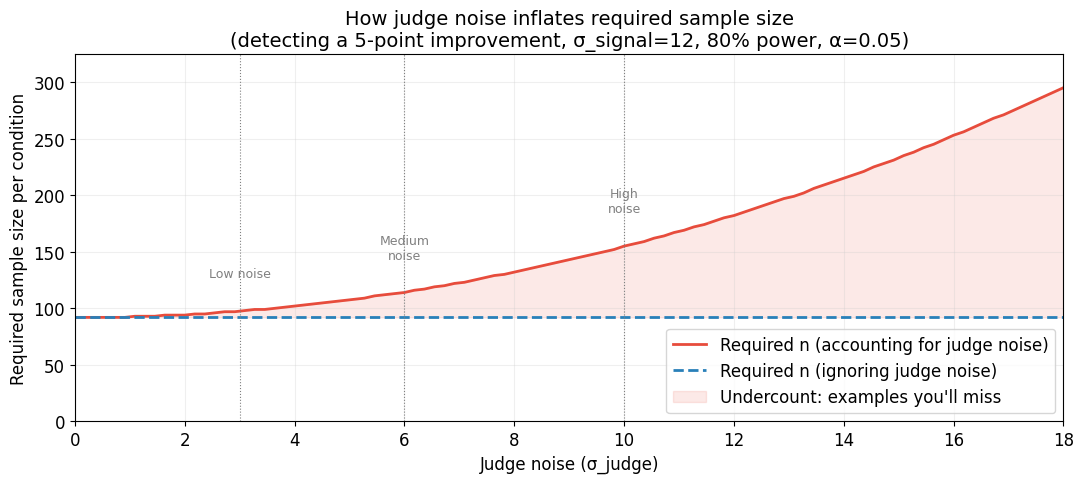

In [13]:
# Sweep sigma_judge from 0 (perfect judge) to 18 (highly inconsistent)
# to show the full shape of the noise-inflation curve
sigma_judges = np.linspace(0, 18, 100)
n_with_noise = []     # what you need (correct calculation)
n_without_noise = []  # what a naive calculation would tell you (wrong)

for sj in sigma_judges:
    r = required_n_judge_based(5.0, 12.0, sj)
    n_with_noise.append(r['n_effective'])
    n_without_noise.append(r['n_naive'])

fig, ax = plt.subplots(figsize=(11, 5))

# Red = what you need. Blue dashed = what the naive calculation says.
# The gap between them is the undercount: the error in most judge-based evals.
ax.plot(sigma_judges, n_with_noise,    color='#e74c3c', label='Required n (accounting for judge noise)')
ax.plot(sigma_judges, n_without_noise, color='#2980b9', linestyle='--', label='Required n (ignoring judge noise)')

# Shaded region makes the undercount visually prominent and easy to reason about
ax.fill_between(sigma_judges, n_without_noise, n_with_noise,
                alpha=0.12, color='#e74c3c', label="Undercount: examples you'll miss")

# Reference annotations at key noise levels, corresponding to rows in the table above
for sj_ref, label in [(3.0, 'Low noise'), (6.0, 'Medium\nnoise'), (10.0, 'High\nnoise')]:
    r = required_n_judge_based(5.0, 12.0, sj_ref)
    ax.axvline(sj_ref, color='gray', linestyle=':', linewidth=0.8)
    ax.text(sj_ref, r['n_effective'] + 30, label, ha='center', fontsize=9, color='gray')

ax.set_xlabel('Judge noise (σ_judge)')
ax.set_ylabel('Required sample size per condition')
ax.set_title('How judge noise inflates required sample size\n(detecting a 5-point improvement, σ_signal=12, 80% power, α=0.05)')
ax.legend()
ax.set_xlim(0, 18)
ax.set_ylim(0, max(n_with_noise) * 1.1)

plt.tight_layout()
plt.show()

### A unified power calculator for LLM evaluation

Wraps all four metric types behind one interface: pass metric type, baseline, expected improvement, and judge noise if applicable, and it returns the required sample size.

If the budget only allows fewer examples: accept lower power, or accept you can only detect larger improvements. Both are legitimate. Make the choice on purpose.

In [14]:
def llm_eval_power_calculator(
    metric_type,          # 'continuous', 'binary', 'ordinal', 'judge'
    baseline_score,       # mean or proportion for baseline
    expected_improvement, # absolute improvement (in score units or percentage points)
    std_dev=None,         # std dev of scores (for continuous/ordinal/judge)
    judge_noise_std=None, # std dev of judge scoring noise (for judge type only)
    alpha=0.05,
    power=0.80,
):
    """
    Unified sample size calculator for LLM evaluation metrics.

    Parameters
    ----------
    metric_type          : 'continuous' | 'binary' | 'ordinal' | 'judge'
    baseline_score       : current score (mean for continuous/ordinal/judge; proportion for binary)
    expected_improvement : minimum detectable improvement you care about
    std_dev              : score standard deviation (required for continuous, ordinal, judge)
    judge_noise_std      : judge noise std dev (required for judge type)
    alpha                : Type I error rate (default 0.05)
    power                : desired power (default 0.80)

    Returns
    -------
    dict with 'required_n_per_group', 'total_required', 'effect_size', 'metric_type'
    """
    result = {'metric_type': metric_type, 'alpha': alpha, 'power': power}
    analysis = TTestIndPower()

    if metric_type == 'binary':
        p_base = baseline_score
        p_impr = baseline_score + expected_improvement
        if not (0 < p_base < 1 and 0 < p_impr < 1):
            raise ValueError("Binary proportions must be strictly between 0 and 1.")
        # Cohen's h for proportions: the correct effect size for binary metrics
        h = abs(proportion_effectsize(p_impr, p_base))
        # NormalIndPower for proportions z-test, NOT TTestIndPower
        norm_analysis = NormalIndPower()
        n = int(np.ceil(norm_analysis.solve_power(
            effect_size=h, alpha=alpha, power=power, alternative='two-sided')))
        result.update({'effect_size': h, 'effect_size_type': "Cohen's h",
                       'required_n_per_group': n, 'total_required': 2 * n})

    elif metric_type == 'continuous':
        if std_dev is None:
            raise ValueError("std_dev required for continuous metrics.")
        # Cohen's d for continuous metrics: the standard effect size for t-tests
        d = expected_improvement / std_dev
        n = int(np.ceil(analysis.solve_power(
            effect_size=d, alpha=alpha, power=power, alternative='two-sided')))
        result.update({'effect_size': d, 'effect_size_type': "Cohen's d",
                       'required_n_per_group': n, 'total_required': 2 * n})

    elif metric_type == 'ordinal':
        if std_dev is None:
            raise ValueError("std_dev required for ordinal metrics.")
        improved_score = baseline_score + expected_improvement
        # Convert to AUC, then to Cohen's d approximation for the Mann-Whitney U test
        auc = estimate_auc_from_scores(baseline_score, improved_score, std_dev)
        d_approx = auc_to_cohens_d(auc)
        n_ttest = analysis.solve_power(
            effect_size=d_approx, alpha=alpha, power=power, alternative='two-sided')
        # Apply Mann-Whitney efficiency penalty for bounded ordinal scales
        n = int(np.ceil(n_ttest / 0.864))
        result.update({'effect_size': d_approx, 'effect_size_type': "d (AUC-derived)",
                       'required_n_per_group': n, 'total_required': 2 * n})

    elif metric_type == 'judge':
        if std_dev is None or judge_noise_std is None:
            raise ValueError("Both std_dev and judge_noise_std required for judge metrics.")
        # Effective std combines signal variance and judge noise variance in quadrature
        sigma_eff = np.sqrt(std_dev**2 + judge_noise_std**2)
        d = expected_improvement / sigma_eff  # use sigma_eff, NOT std_dev alone
        n = int(np.ceil(analysis.solve_power(
            effect_size=d, alpha=alpha, power=power, alternative='two-sided')))
        result.update({'effect_size': d, 'effect_size_type': "Cohen's d (eff)",
                       'sigma_effective': sigma_eff,
                       'required_n_per_group': n, 'total_required': 2 * n})

    else:
        raise ValueError(f"Unknown metric_type '{metric_type}'. Choose: continuous, binary, ordinal, judge.")

    return result


# --- Demo: four evaluation scenarios representing common production situations ---
demos = [
    # Binary: factual accuracy evaluation, common in QA pipelines
    dict(metric_type='binary',     baseline_score=0.72, expected_improvement=0.08,
         description="Factual accuracy: 72% → 80%"),
    # Continuous: relevance score, RAG evaluation with numeric scores
    dict(metric_type='continuous', baseline_score=65.0, expected_improvement=5.0,  std_dev=15.0,
         description="Relevance: 65 → 70 on 0–100 scale"),
    # Ordinal: coherence rubric, human or LLM judge on 1-5 integer scale
    dict(metric_type='ordinal',    baseline_score=3.5,  expected_improvement=0.3,  std_dev=0.90,
         description="Coherence: 3.5 → 3.8 on 1–5 rubric"),
    # Judge: helpfulness with GPT-4 noise, most common production scenario
    dict(metric_type='judge',      baseline_score=60.0, expected_improvement=5.0,  std_dev=12.0,
         judge_noise_std=6.0,
         description="Judge-scored helpfulness: 60 → 65 (with GPT-4 noise)"),
]

print("=" * 75)
print("LLM EVAL POWER CALCULATOR: demo results")
print("=" * 75)

for demo in demos:
    desc = demo.pop('description')
    r = llm_eval_power_calculator(**demo)
    print(f"\nScenario: {desc}")
    print(f"  Metric type:       {r['metric_type']}")
    print(f"  Effect size:       {r['effect_size']:.3f} ({r['effect_size_type']})")
    print(f"  Required n:        {r['required_n_per_group']:,} per group")
    print(f"  Total test cases:  {r['total_required']:,}")

LLM EVAL POWER CALCULATOR: demo results

Scenario: Factual accuracy: 72% → 80%
  Metric type:       binary
  Effect size:       0.188 (Cohen's h)
  Required n:        445 per group
  Total test cases:  890

Scenario: Relevance: 65 → 70 on 0–100 scale
  Metric type:       continuous
  Effect size:       0.333 (Cohen's d)
  Required n:        143 per group
  Total test cases:  286

Scenario: Coherence: 3.5 → 3.8 on 1–5 rubric
  Metric type:       ordinal
  Effect size:       0.333 (d (AUC-derived))
  Required n:        165 per group
  Total test cases:  330

Scenario: Judge-scored helpfulness: 60 → 65 (with GPT-4 noise)
  Metric type:       judge
  Effect size:       0.373 (Cohen's d (eff))
  Required n:        114 per group
  Total test cases:  228


**KEY INSIGHT: The metric type changes the answer dramatically**

Judge-scored helpfulness and continuous relevance share the same 5-point improvement and similar std (~12 vs 15), but judge noise inflates the effective std, so judge-based needs substantially more examples. The metric type, not just the size of the improvement, determines n. The wrong method gives the wrong sample size, and an unreliable conclusion.

---

## Section 5: The Takeaway

### Rules of thumb for LLM evaluation sample sizes

- **200 examples is the floor, not the target.** At n=200 per condition, you get roughly 80% power for a medium effect (d≈0.40). Small effects need 800–1,000.
- **An underpowered eval doesn't just miss a result, it makes the wrong decision.** A 10%-powered experiment misses an improvement that exists roughly 90% of the time.
- **Calculate required n before you collect data, not after.** Testing, getting p=0.08, then collecting more data to push below 0.05 is p-hacking, and it inflates the Type I error rate.

Next step: pick your next eval, name the metric type, minimum improvement, and baseline std, then run `llm_eval_power_calculator` for it.

---

### What this notebook did not cover

Three extensions live in the book:

- **Sequential testing** (Chapter 5): stop an experiment early without inflating the Type I error rate.
- **Variance reduction** (Chapter 5): stratification and control variates that cut σ without adding examples.
- **Bayesian alternatives** (Chapter 6): a posterior distribution over effect sizes instead of a binary reject/fail-to-reject decision.

### Quick reference

| Metric type | Power method | Effect size measure | Minimum n (medium effect) |
|---|---|---|---|
| Continuous (0–100, floats) | Two-sample t-test | Cohen's d | ~200 |
| Binary (pass/fail) | Proportions z-test | Cohen's h | ~200 |
| Ordinal (1–5 rubric) | Mann-Whitney U | d via AUC | ~230 |
| Judge-scored | t-test with σ_eff | Cohen's d (eff) | 200–600+ |

All figures assume α = 0.05, two-sided, 80% power.

---

*This notebook accompanies the O'Reilly Live Course: **Statistical Testing for LLM Evaluations: Design experiments that catch the improvements worth shipping**, by Rudrendu Paul.*
*For the full treatment of sample size, power, sequential testing, and variance reduction, see the companion book: **Statistical Evaluation Methods for AI Systems** (Paul, O'Reilly, forthcoming).*